### Building a Chip

In [60]:
import gdspy
import qnldraw as qd 

import qnldraw.library as qlib 
from qnldraw import Chip, paths

In [61]:
chip = Chip()

launch = qlib.Launch( 
    cpw={'width': 20, 'gap': 10}, 
    bondpad={'width': 125, 'length': 125, 'gap': 56.5}, 
    taper_length=100
)

launch1 = launch.place((-4500, 0))
cpw = paths.CPW(**launch.get_params('cpw'), start=launch1.node('cpw')).segment(9000)
launch2 = launch.place(cpw.current_position(), mirror='y')
chip.add_component([launch1, launch2, cpw], cid = 'TRANSMISSION_LINE');

In [62]:
qubit = qlib.FloatingPads( 
    pads={'x': 135, 'y': 545}, 
    cutout={'x': 545, 'y': 745}, 
    spacing=65
).place((0, -50), 'cutout_right', rotation=90)

chip.add_component(qubit, cid = 'QUBIT')

mask = chip.render('MASK', draw_border=True)

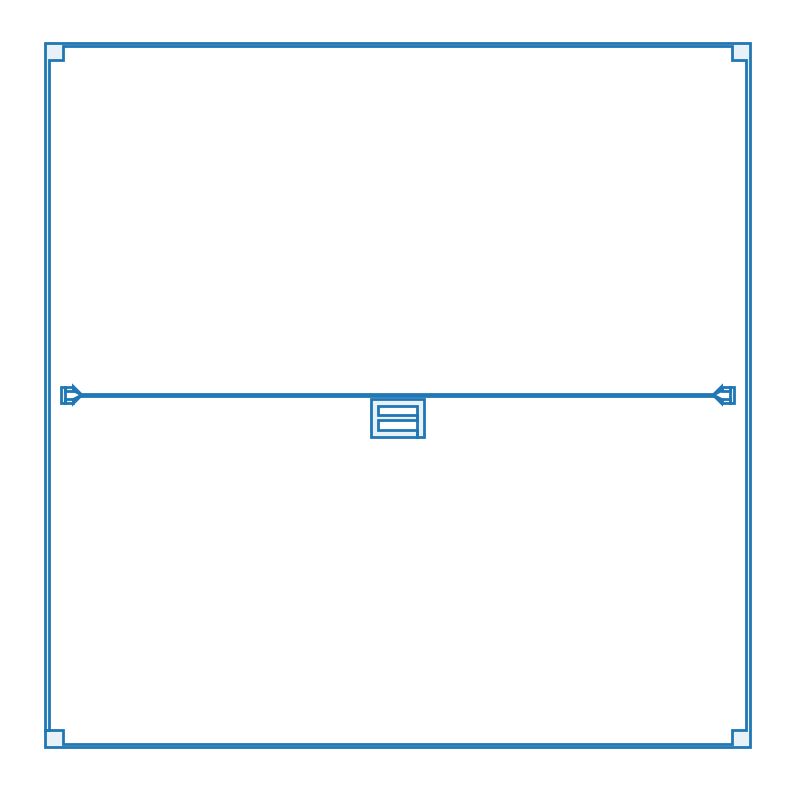

In [63]:
fig = qd.plot(mask[0], figsize = (10, 10), axis = False)

---

In [72]:
from qnldraw import shapes, components

chip = qd.Chip() # defaults to 10mm x 10mm with 50 µm border

In [104]:
tline = components.Component(name = 'TransmissionLine')
cpw = {'width': 20, 'gap': 10}

launch = qlib.Launch(
    cpw=cpw, 
    bondpad={'width': 125, 
             'length': 125, 
             'gap': 56.5}, 
             taper_length = 100
)

l1 = launch.place((0, 4800), node = 'cutout', rotation = -90)
l2 = launch.place((0, -4800), node = 'cutout', rotation = 90)
trace = paths.CPW.between(l1.node('cpw'), l2.node('cpw'), **cpw)

tline.add([l1, l2, trace])

qbpads = qlib.FloatingPads(
    pads={'x': 135, 'y': 545}, 
    cutout={'x': 545, 'y': 745}, 
    spacing=65
)

ys=np.linspace(-3000, 3000, 4)
xs={0:-100, 1:100}
node = {0: 'cutout_right', 1: 'cutout_left'}
qubits = [qbpads.place((xs[i%2], y), node=node[i%2]) for i, y in enumerate(ys)]
qubits

[ComponentRef("FloatingPads[26]", at (-372.5, -3000.0), rotation 0.0, magnification None, x_reflection False),
 ComponentRef("FloatingPads[26]", at (372.5, -1000.0), rotation 0.0, magnification None, x_reflection False),
 ComponentRef("FloatingPads[26]", at (-372.5, 1000.0), rotation 0.0, magnification None, x_reflection False),
 ComponentRef("FloatingPads[26]", at (372.5, 3000.0), rotation 0.0, magnification None, x_reflection False)]

In [105]:
chip = qd.Chip()

chip.add_component(tline, cid='Transmission', layers = 1)

for i, qb in enumerate(qubits): 
    chip.add_component(qb, f'Q{i}', layers = 2)

mask = chip.render('mask', draw_border=True)

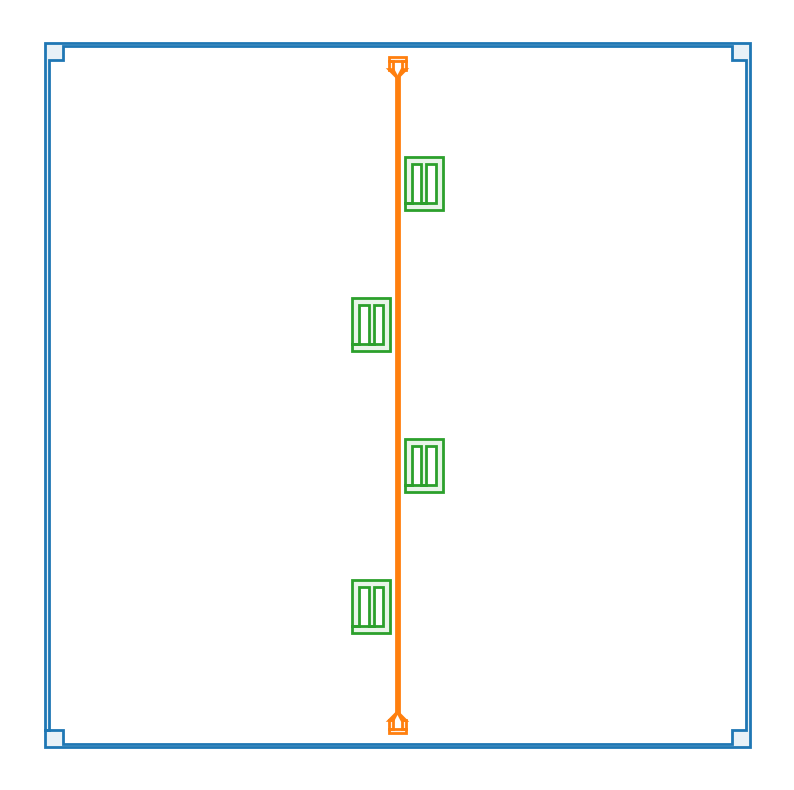

In [106]:
fig = qd.plot(mask[0], figsize=(10,10), axis=False)

---

### Components 

In [107]:
import qnldraw.library as qlib

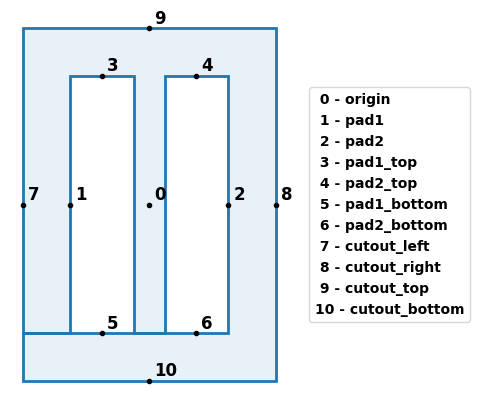

In [109]:
fig = qlib.FloatingPads.document()

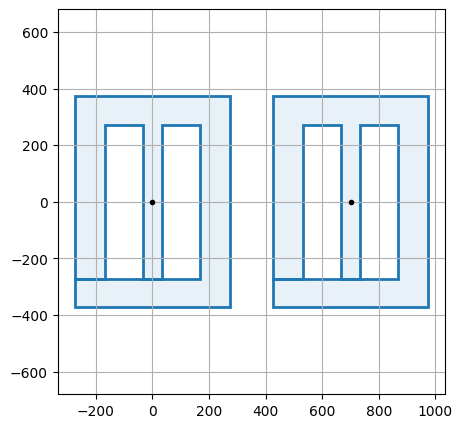

In [135]:
# creating a floatingpads component

qbpads = qlib.FloatingPads(
    pads = {'x': 135, 'y': 545}, 
    cutout = {'x': 545, 'y': 745}, 
    spacing = 65
)

Q0 = qbpads.place()
Q1 = qbpads.place((700, 0))

fig = qd.plot([Q0, Q1])
ax = fig.axes[0]
ax.plot(*Q0.node('origin'), '.k', *Q1.node('origin'), '.k')

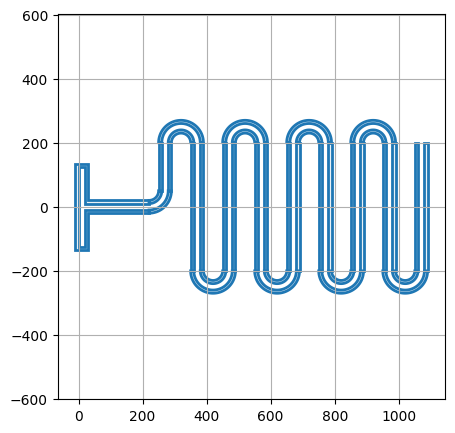

In [136]:
class QWResonator(components.Component):
    # This tells the __init__ method to call draw() upon initialization
    __draw__ = True

    def draw(self, cpw, coupling_pad, neck, meander):
        # The pad width will be the same as the `CPW` width
        coupling_pad['pad'].update(width=cpw['width'])

        # Define a coupling pad subcomponent
        cpad = qlib.CouplingPad(
            cpw=cpw, cpw_length=neck, pad=coupling_pad['pad'], gap=cpw['gap'], name='PAD'
        ).place(node='pad', rotation=90)

        # Define the CPW trace
        trace = paths.CPW(**cpw, start=cpad.node('cpw')) \
            .turn(meander['radius'], 'l') \
            .segment(150) \
            .meander(**meander)

        # Add all elements to the component cell.
        self.add([cpad, trace])
        # Add the CPW cutout to the component.
        self.add_cutout(trace.cutout)

        nodes = {
            'end': trace.current_position(),
        }
        # draw() should return a dictionary of nodes. The origin in 
        # the compononent's reference frame is automatically added to the
        # dictionary with the key 'origin'.
        # subcomponent nodes area also automatically added
        return nodes

qw_res = QWResonator(
    cpw={'width': 20, 'gap': 10},
    ## The other parameters in coupling pad are automatically computed
    coupling_pad={'pad': {'length': 250}},
    neck=200,
    meander={
        'num_segments': 8,
        'length': 400, 
        'radius': 50,
        'turn': -1,
        'extra_turns': 'start'
    }
)

fig = qd.plot(qw_res)

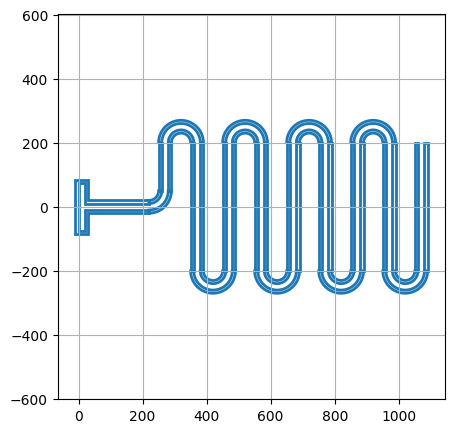

In [153]:
cpw = {'width': 20, 'gap': 10}

coupling_pad = qlib.CouplingPad(
    cpw=cpw,
    cpw_length=200,
    pad={'width': cpw['width'], 'length': 150},
    gap=10
).place(node='pad', rotation=90)

trace = paths.CPW(**cpw, start=coupling_pad.node('cpw')) \
    .turn(50, 'l') \
    .segment(150) \
    .meander(8, 400, 50, turn=-1, extra_turns='start')

qw_res = components.Component(name='QWResonator')
qw_res.add([coupling_pad, trace])
qw_res.add_cutout(trace.cutout)

fig = qd.plot(qw_res)